
Given the root of a Binary Search Tree, we need to insert a new node with given value in the BST. All the nodes have distinct values in the BST and we may assume that the the new value to be inserted is not present in BST.

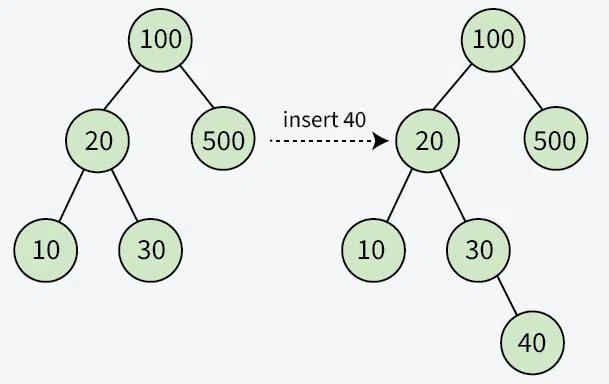

A new key is inserted at the position that maintains the BST property. 

We start from the root and move downward: if the key is smaller, go left; if larger, go right.

We continue until we find an unoccupied spot where the node can be placed without violating the BST property, and insert it there as a new leaf.


In [ ]:
class Node:
    def __init__(self, val):
        self.val = val 
        self.left = None 
        self.right = None
        
# Insertion into a binary search tree usng recursion
def insert (root, key):
    # chck if the tree is empty 
    if root is None:
        return Node(key)
    
    # tree not empty? then, stroll down the tree
    if key < root.val:
        root.left = insert(root.left, key)
    else:
        root.right = insert(root.right, key)

    return root

if __name__ == "__main__":

    root = Node(22)
    root.left = Node(12)
    root.right = Node(30)
    root.left.left = Node(8)
    root.left.right = Node(20)
    root.left.right.right = Node(30) 
    key = 15

    insert(root, 15)



Time Complexity: O(h)

    The worst-case time complexity of insert operations is O(h) where h is the height of the Binary Search Tree. 
    In the worst case, we may have to travel from the root to the deepest leaf node. The height of a skewed tree may become n and the time complexity of insertion operation may become O(n). 

Auxiliary Space: O(h), due to recursive stack.

### Insertion in Binary Search Tree using Iterative approach:

    Instead of using recursion, we can also implement the insertion operation iteratively using a while loop. 
Below is the implementation using a while loop, using the same idea as above.

In [ ]:
class Node: 
    def __init__(self, val):
        self.val = val 
        self.left - None 
        self.right = None 

def insert(root, key):
    temp = Node(key)

    if root is None:
        return temp 
    
    curr = root 
    while curr is not None:
        if curr.data > key and curr.left is not None:
            curr = curr.left 

        elif curr.data < key and curr.right is not None:
            curr = curr.right 
        else:
            break 
    
    if curr.data > key:
        curr.left = temp 
    else:
        curr.right = temp
    
    return root





### Searching in Binary Search Tree (BST)

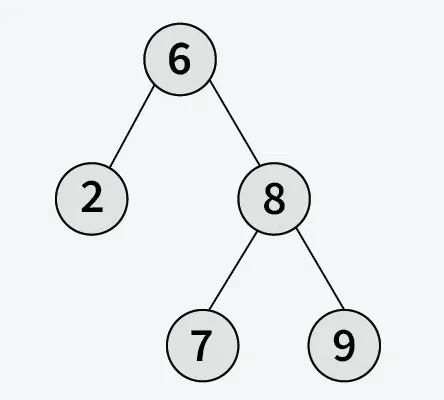

Given the root of a Binary Search Tree and a Value Key, find if the key is present in the BST or not.
Note: The key may or may not be present in the key. 

Input: key = 7
Output: true
Explanation: 7 is present in the BST.

Input: key = 14
Output: false
Explanation: 14 is not present in the BST.

#### Two Types - Recursive Search & Iterative Search 

In [5]:
class Node: 
    def __init__(self, val):
        self.val = val 
        self.left = None 
        self.right = None 

# Recursive implmentation of the search 
def recursiveSearch(root, key):
    if not root:
        return "tree is empty"
    if root.val == key:
        return True 
    if key > root.val:
        return recursiveSearch(root.right, key)

    return recursiveSearch(root.left, key)

# iterative implementation of the search 
def iterativeSearch(root, key):
    present = "Tree is Empty" 

    # iterative traversal 
    while root:
        if root.val == key:
            present = True 
            break 
        elif key > root.val:
            root = root.right 
        else:
            root = root.left 
    return present



# Creating BST
#     6
#   / \
#   2   8
#      / \
#     7   9
root = Node(6)
root.left = Node(2)
root.right = Node(8)
root.right.left = Node(7)
root.right.right = Node(9)

key = 7
# Searching for key in the BST
print(recursiveSearch(root, key))
print(recursiveSearch(root, 14))

print(iterativeSearch(root, key))
print(iterativeSearch(root, 34))


True
tree is empty
True
Tree is Empty


For the recursive method:
    Time complexity: O(h), where h is the height of the BST.
    Auxiliary Space: O(h) This is because of the space needed to store the recursion stack.

For the iterative method:
    We can avoid the auxiliary space and recursion overhead withe help of iterative implementation. Below is the iterative implementation that works in O(h) time and O(1) auxiliary space.


### Deletion from a Binary Search Tree

Given the root of a Binary Search Tree (BST) and an integer x, delete the node with value x from the BST while maintaining the BST property.

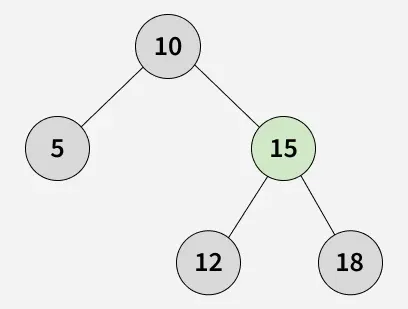

Input: x = 15
Output: [[10], [5, 18], [N, N, 12, N]]
Explanation:  The node with value x (15) is deleted from BST.

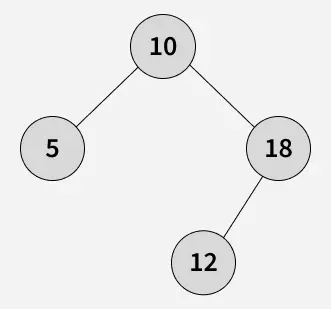

Deleting a node in a BST means removing the target node while ensuring that the tree remains a valid BST. Depending on the structure of the node to be deleted, there are three possible scenarios:

Case 1: Node has No Children (Leaf Node)

    If the target node is a leaf node, it can be directly removed from the tree since it has no child to maintain.

Case 2: Node has One Child(Left or Right Child)

    If the target node has only one child, we remove the node and connect its parent directly to its only child. This way, the tree remains valid after deletion of target node.

Case 3: Node has Two Children

    If the target node has two children, deletion is slightly more complex.

To maintain the BST property, we need to find a replacement node for the target. The replacement can be either:

    The inorder successor — the smallest value in the right subtree, which is the next greater value than the target node.
    The inorder predecessor — the largest value in the left subtree, which is the next smaller value than the target node.  

Once the replacement node is chosen, we replace the target node’s value with that node’s value, and then delete the replacement node, which will now fall under Case 1 (no children) or Case 2 (one child).

Note: Inorder predecessor can also be used.

Working:

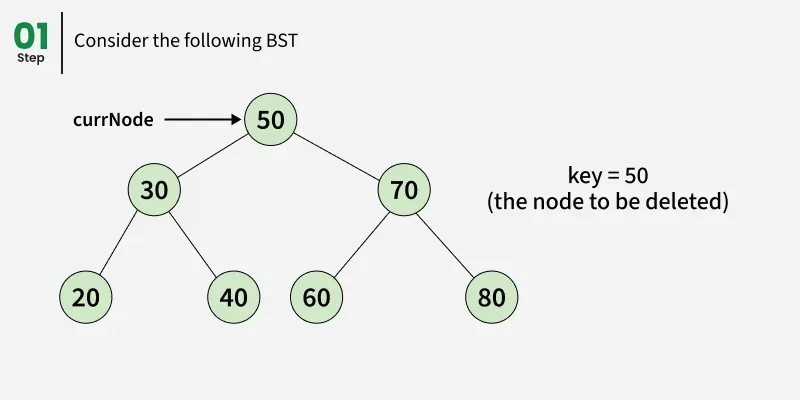

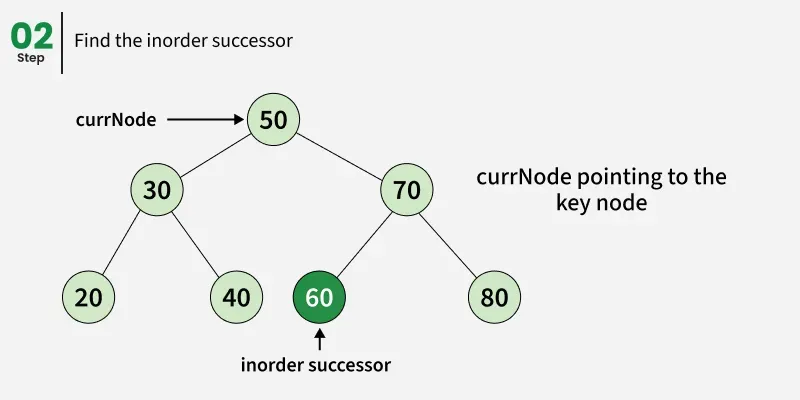

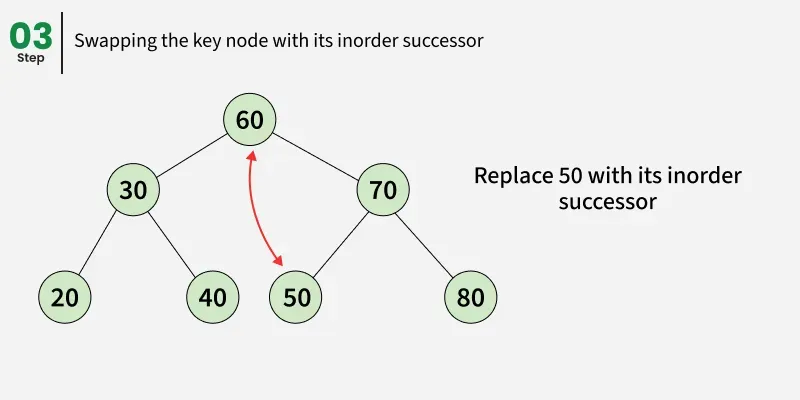

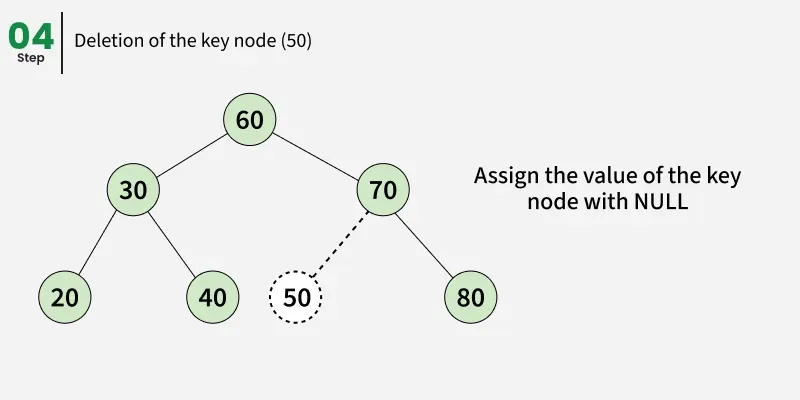

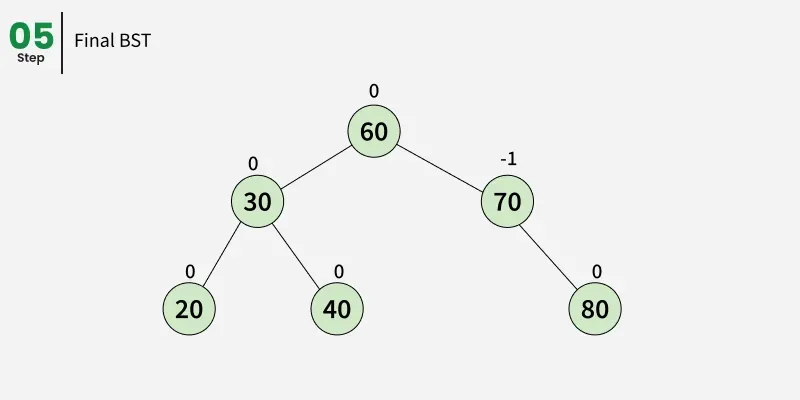

The deletion process in BST depends on the number of children of the node.

    No children means simply remove the node.
    One child means remove the node and connect its parent to the node’s only child.
    Two children means replace the node with its inorder successor/predecessor and delete that node.

This ensures that the BST property remains intact after every deletion.


In [9]:
class Node:
    def __init__(self, val):
        self.data = val 
        self.left = None 
        self.right = None 

def insert(root, key):
    temp = Node(key)

    if root is None:
        return temp 
    
    curr = root 
    while curr is not None:
        if curr.data > key and curr.left is not None:
            curr = curr.left 

        elif curr.data < key and curr.right is not None:
            curr = curr.right 
        else:
            break 
    
    if curr.data > key:
        curr.left = temp 
    else:
        curr.right = temp
    
    return root

# Get inorder successor (smallest in right subtree or the node with nearest bigger 
# value than the node to be deleted)
def getSuccessor(curr):
    curr = curr.right 
    while curr is not None and curr.left is not None:
        curr = curr.left 
    return curr 

# delete the node with value x from the BST
def delNode(root, x):
    if root is None:
        return root 

    if root.data > x:
        root.left = delNode(root.left, x)
    elif root.data < x:
        root.right = delNode(root.right, x)
    else:
        # node with 0 or 1 children 
        if root.left is None:
            return root.right
        if root.right is None:
            return root.left 
        
        # Node with 2 children 
        succ = getSuccessor(root)
        root.data = succ.data
        root.right = delNode(root.right, succ.data)
    return root


# Creating BST
#     6
#   / \
#   2   8
#      / \
#     7   9
root = Node(6)
root.left = Node(2)
root.right = Node(8)
root.right.left = Node(7)
root.right.right = Node(9)

key = 7
# Searching for key in the BST
deleted = delNode(root, key)
print (deleted.data)        
     

6


In [ ]:
# Challenge: write the delete algorithm without the recursion

Reference 

https://www.geeksforgeeks.org/dsa/binary-search-tree-data-structure/
